In [2]:
from funciones import procesar_datos_termo
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Rutas a archivos 
carpeta = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P14_Polimero_Solvente'
archivo = 'log_Poly-Solv_T0.50_epsSP0.10_monom_8.csv'
ruta_archivo = os.path.join(carpeta, archivo)

In [4]:
procesar_datos_termo(archivo_csv=ruta_archivo)

{'nombre': 'log_Poly-Solv_T0.50_epsSP0.10_monom_8',
 'step': array([     0,  10000,  20000,  30000,  40000,  50000,  60000,  70000,
         80000,  90000, 100000, 110000, 120000, 130000, 140000, 150000,
        160000, 170000, 180000, 190000, 200000]),
 'pe': array([-7167550., -7574520., -7666440., -7682510., -7726020., -7804240.,
        -7917850., -8069270., -8240530., -8385740., -8459250., -8479830.,
        -8491700., -8498740., -8505110., -8507510., -8511960., -8514840.,
        -8517490., -8520550., -8522180.])}

In [5]:
df = pd.read_csv(ruta_archivo, sep=r'\s+', engine='python')
num_filas = df.shape[0]
encabezados = df.head()
print(f'El csv tiene {num_filas} filas ({num_filas*10_000})')
print(f'Los encabezados son: {encabezados}')

df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce').dropna().reset_index(drop=True)
cols_step = [c for c in df.columns if 'step' in c.lower()]

if cols_step:
    step = df[cols_step[0]]
else:
    print("⚠️ Columna 'timestep' no encontrada en el CSV. Reconstruyendo eje X cada 10k pasos.")
    step = df.index * 10000  # <--- Esto mapea el eje X con tus datos reales de 10k en 10k

col_pe = [c for c in df.columns if 'potential' in c.lower()][0]
col_ke = [c for c in df.columns if 'kinetic_energy' in c.lower() or 'kinetic_' in c.lower() and 'temperature' not in c.lower()][0]
col_pres = [c for c in df.columns if 'pressure' in c.lower()]
kinetic_temp = [c for c in df.columns if 'kinetic_temperature' in c.lower()]

k_temp = df[kinetic_temp]        
pe = df[col_pe]
ke = df[col_ke]
etot = pe + ke
press = df[col_pres[0]] if col_pres else np.zeros(len(df))

El csv tiene 21 filas (210000)
Los encabezados son:    md.compute.ThermodynamicQuantities.potential_energy  \
0                                         -7167550.0     
1                                         -7574520.0     
2                                         -7666440.0     
3                                         -7682510.0     
4                                         -7726020.0     

   md.compute.ThermodynamicQuantities.kinetic_energy  \
0                                           900573.0   
1                                           901667.0   
2                                           900155.0   
3                                           900570.0   
4                                           900034.0   

   md.compute.ThermodynamicQuantities.kinetic_temperature  \
0                                            0.50032        
1                                            0.50093        
2                                            0.50009        
3                 

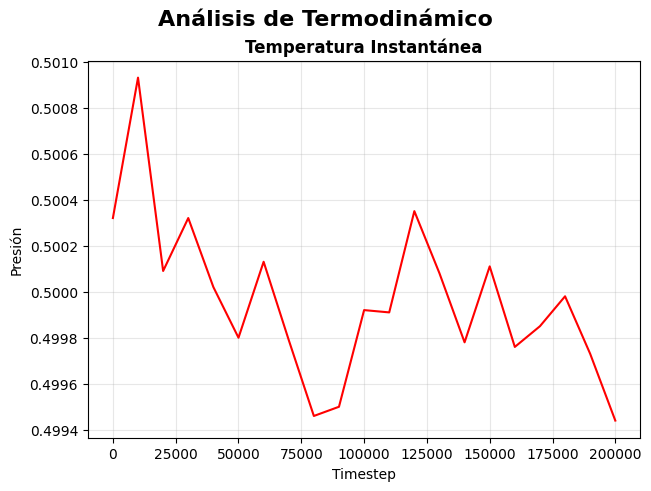

In [ ]:
fig, axs = plt.subplots(layout='constrained')
t_titulo = os.path.basename(archivo).replace('.csv', '')
fig.suptitle(f'Análisis de Termodinámico', fontsize=16, fontweight='bold')

# Diccionario para iterar los paneles fácilmente
datasets = [
    (k_temp, 'Temperatura Instantánea', 'red', axs),
]

for data, title, color, ax in datasets:
    # Graficar toda la serie
    ax.plot(step, data, color=color, alpha=1.0, label='Equilibración')
    
    ax.set_title(title, fontweight='semibold')
    ax.set_ylabel('Presión')
    ax.set_xlabel('Timestep')
    ax.grid(True, alpha=0.3)
    if title == 'Energía Total': ax.legend(loc='best')

    # Guardar resultado
    # (Asegúrate de que ruta_graficos esté definida en tu script principal)
plt.show()


## **T=0.60, Eps=0.5 y 1.0**

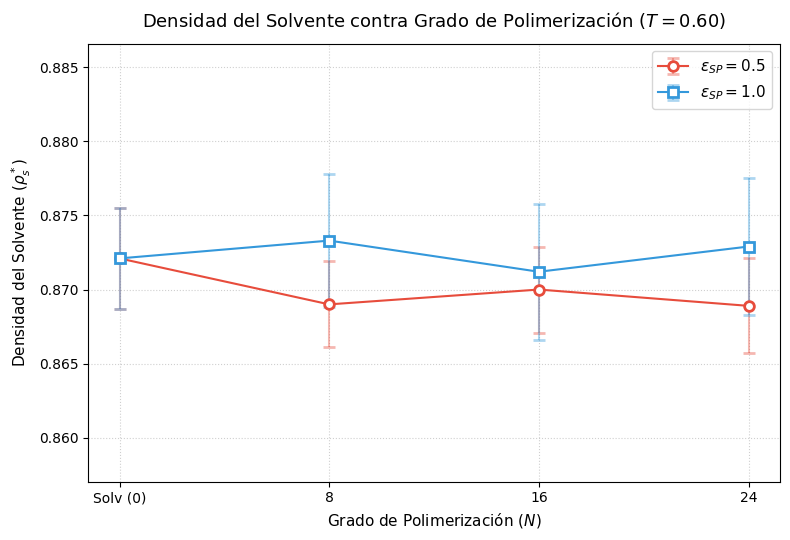

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupando los datos proporcionados en un diccionario
datos_polimero_0_5 = {
    'grado_polimerizacion': np.array([0, 8, 16, 24]),
    'densidades_solvente': np.array([0.8721, 0.8690, 0.8700, 0.8689]),
    'densidades_std': np.array([0.00343, 0.0029, 0.0029, 0.0032])
}

datos_polimero_1_0 = {
    'grado_polimerizacion': np.array([0, 8, 16, 24]),
    'densidades_solvente': np.array([0.8721, 0.8733, 0.8712, 0.8729]),
    'densidades_std': np.array([0.00343, 0.0045, 0.0046, 0.0046])
}

# Configuración del gráfico
plt.figure(figsize=(8, 5.5))

# 1. Grupo Épsilon = 0.5 (Color Naranja/Rojizo)
plt.errorbar(
    datos_polimero_0_5['grado_polimerizacion'],
    datos_polimero_0_5['densidades_solvente'],
    yerr=datos_polimero_0_5['densidades_std'],
    fmt='o-',            # Círculos unidos por líneas continuas
    color='#e74c3c',  
    ecolor=(0.91, 0.30, 0.24, 0.4),   
    elinewidth=1.5,       
    capsize=4,          
    markersize=7,       
    markerfacecolor='white', 
    markeredgewidth=2,
    label=r'$\epsilon_{SP} = 0.5$'
)

# 2. Grupo Épsilon = 1.0 (Color Azul)
plt.errorbar(
    datos_polimero_1_0['grado_polimerizacion'],
    datos_polimero_1_0['densidades_solvente'],
    yerr=datos_polimero_1_0['densidades_std'],
    fmt='s-',            # Cuadrados unidos por líneas continuas
    color='#3498db',  
    ecolor=(0.20, 0.60, 0.86, 0.4),   
    elinewidth=1.5,       
    capsize=4,          
    markersize=7,       
    markerfacecolor='white', 
    markeredgewidth=2,
    label=r'$\epsilon_{SP} = 1.0$'
)

# Títulos y etiquetas generales
plt.title(r'Densidad del Solvente contra Grado de Polimerización ($T = 0.60$)', fontsize=13, pad=12)
plt.xlabel('Grado de Polimerización ($N$)', fontsize=11)
plt.ylabel(r'Densidad del Solvente ($\rho_s^*$)', fontsize=11)

# Personalización de la cuadrícula y ejes
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(datos_polimero_0_5['grado_polimerizacion'], ['Solv (0)', '8', '16', '24']) 

# Ajuste global de los límites del eje Y considerando ambos grupos
todos_min = np.minimum(
    datos_polimero_0_5['densidades_solvente'] - datos_polimero_0_5['densidades_std'],
    datos_polimero_1_0['densidades_solvente'] - datos_polimero_1_0['densidades_std']
)
todos_max = np.maximum(
    datos_polimero_0_5['densidades_solvente'] + datos_polimero_0_5['densidades_std'],
    datos_polimero_1_0['densidades_solvente'] + datos_polimero_1_0['densidades_std']
)
plt.ylim(np.min(todos_min) * 0.99, np.max(todos_max) * 1.01) 

# Habilitar la leyenda para identificar cada épsilon
plt.legend(frameon=True, fontsize=11, loc='best')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

## **T=0.65, Eps=0.5 y 1.0**

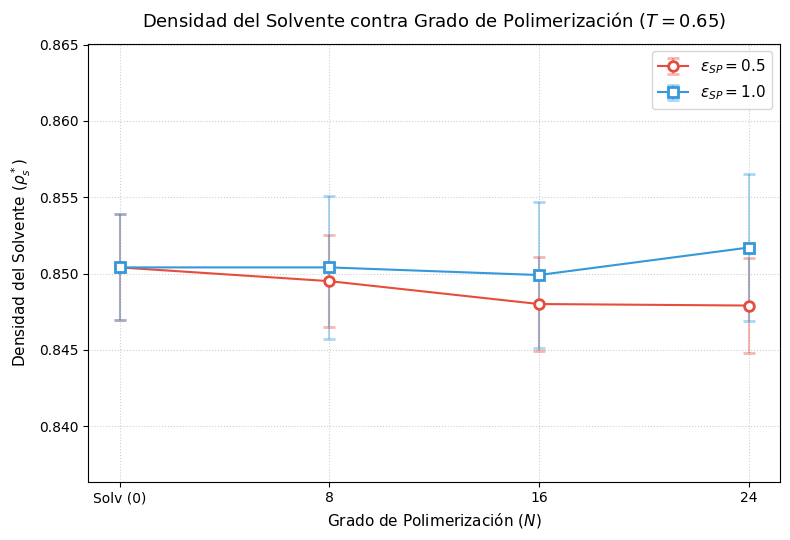

In [ ]:
# Agrupando los datos proporcionados en un diccionario
datos_polimero_0_5 = {
    'grado_polimerizacion': np.array([0,        8,          16,         24]),
    'densidades_solvente':  np.array([0.8504,   0.8495,     0.8480,     0.8479]),
    'densidades_std':       np.array([0.00348,  0.0030,     0.0031,     0.0031])
}

datos_polimero_1_0 = {
    'grado_polimerizacion': np.array([0,        8,          16,         24]),
    'densidades_solvente':  np.array([0.8504,   0.8504,     0.8499,     0.8517]),
    'densidades_std':       np.array([0.00348,  0.0047,     0.0048,     0.0048])
}

# Configuración del gráfico
plt.figure(figsize=(8, 5.5))

# 1. Grupo Épsilon = 0.5 (Color Naranja/Rojizo)
plt.errorbar(
    datos_polimero_0_5['grado_polimerizacion'],
    datos_polimero_0_5['densidades_solvente'],
    yerr=datos_polimero_0_5['densidades_std'],
    fmt='o-',            # Círculos unidos por líneas continuas
    color='#e74c3c',  
    ecolor=(0.91, 0.30, 0.24, 0.4),   
    elinewidth=1.5,       
    capsize=4,          
    markersize=7,       
    markerfacecolor='white', 
    markeredgewidth=2,
    label=r'$\epsilon_{SP} = 0.5$',
    
)

# 2. Grupo Épsilon = 1.0 (Color Azul)
plt.errorbar(
    datos_polimero_1_0['grado_polimerizacion'],
    datos_polimero_1_0['densidades_solvente'],
    yerr=datos_polimero_1_0['densidades_std'],
    fmt='s-',            # Cuadrados unidos por líneas continuas
    color='#3498db',  
    ecolor=(0.20, 0.60, 0.86, 0.4),   
    elinewidth=1.5,       
    capsize=4,          
    markersize=7,       
    markerfacecolor='white', 
    markeredgewidth=2,
    label=r'$\epsilon_{SP} = 1.0$',
    
)

# Títulos y etiquetas generales
plt.title(r'Densidad del Solvente contra Grado de Polimerización ($T = 0.65$)', fontsize=13, pad=12)
plt.xlabel('Grado de Polimerización ($N$)', fontsize=11)
plt.ylabel(r'Densidad del Solvente ($\rho_s^*$)', fontsize=11)

# Personalización de la cuadrícula y ejes
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(datos_polimero_0_5['grado_polimerizacion'], ['Solv (0)', '8', '16', '24']) 

# Ajuste global de los límites del eje Y considerando ambos grupos
todos_min = np.minimum(
    datos_polimero_0_5['densidades_solvente'] - datos_polimero_0_5['densidades_std'],
    datos_polimero_1_0['densidades_solvente'] - datos_polimero_1_0['densidades_std']
)
todos_max = np.maximum(
    datos_polimero_0_5['densidades_solvente'] + datos_polimero_0_5['densidades_std'],
    datos_polimero_1_0['densidades_solvente'] + datos_polimero_1_0['densidades_std']
)
plt.ylim(np.min(todos_min) * 0.99, np.max(todos_max) * 1.01) 

# Habilitar la leyenda para identificar cada épsilon
plt.legend(frameon=True, fontsize=11, loc='best')

# Mostrar el gráfico
plt.tight_layout()
plt.show()